# Introducción a la Ciencia de Datos: Tarea 2

Este notebook contiene el código de base para realizar la Tarea 2 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd/).

**Se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.


## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd/)). Para la entrega 2 hay nuevas dependencias, por lo que es importante correr la siguiente celda.

In [3]:
!pip install -r requirments.txt

  Using cached fqdn-1.5.1-py3-none-any.whl.metadata (1.4 kB)
  Using cached isoduration-20.11.0-py3-none-any.whl.metadata (5.7 kB)
  Using cached uri_template-1.3.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached webcolors-24.11.1-py3-none-any.whl.metadata (2.2 kB)
Using cached webcolors-24.11.1-py3-none-any.whl (14 kB)
Using cached fqdn-1.5.1-py3-none-any.whl (9.1 kB)
Using cached isoduration-20.11.0-py3-none-any.whl (11 kB)
Using cached uri_template-1.3.0-py3-none-any.whl (11 kB)


In [6]:
import re
import os

from time import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
import nltk
import matplotlib.patches as mpatches


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import PCA
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

## Lectura de Datos

In [9]:
# DataFrame con todos los discursos:
df_speeches = pd.read_csv('../data/us_2020_election_speeches.csv')
df_speeches

,speaker,title,text,date,location,type
0,David Perdue,Georgia Sen. David Perdue Speech Transcript at...,David Perdue: (00:01)\nHow great is it to be b...,"Oct 16, 2020","Macon, Georgia",Campaign Speech
1,Joe Biden,"Joe Biden Southfield, MI Speech on Health Care...","Joe Biden: (00:00)\nHello, Michigan. Hi, how a...","Oct 16, 2020","Southfield ,Michigan",Campaign Speech
2,Donald Trump,Donald Trump Speech Transcript ‘Protecting Ame...,President Trump: (00:30)\nThank you. What a ni...,"Oct 16, 2020","Fort Myers, Florida",Campaign Speech
3,Joe Biden,Joe Biden ABC Town Hall Transcript October 15,"George Stephanopoulos: (00:41)\nHey, and welco...","Oct 15, 2020",ABC,Town Hall
4,Donald Trump,Donald Trump NBC Town Hall Transcript October 15,Savannah Guthrie: (03:50)\nIt’s nothing but no...,"Oct 15, 2020",NBC,Town Hall
...,...,...,...,...,...,...
264,Bernie Sanders,Bernie Sanders Speech Transcript: Sanders Spea...,Bernie Sanders: (00:00)\nJust want to take thi...,"Feb 6, 2020",Iowa,Campaign Speech
265,Democratic Candidates,Transcript: Speeches at the Iowa Caucuses – Be...,Bernie Sanders: (00:08)\nThank you. Thank you....,"Feb 4, 2020",Iowa,Campaign Speech
266,Donald Trump,Donal Trump Iowa Rally Transcript: Trump Holds...,Donald Trump: (00:24)\nI worked so hard for th...,"Jan 30, 2020","Des Moines, Iowa",Campaign Speech
267,Donald Trump,Donald Trump New Jersey Rally Speech Transcrip...,Donald Trump: (01:22)\nThank you. Thank you. I...,"Jan 28, 2020","Wildwood, New Jersey",Campaign Speech


In [14]:
def clean_text(df, column_name):
    result = df[column_name]

    # quitar todo hasta el primer \n (introducción del texto, que a veces repite el orador)
    result = result.str.replace(r"^[^\n]*\n", "", regex=True)

    # convertir a minúsculas
    result = result.str.lower()

    # eliminar encabezados del orador tipo "joe biden:" con espacios
    result = result.str.replace(
        r"\b(joe biden|donald trump|kamala harris|mike pence|bernie sanders|president trump)\s*:", 
        "", 
        regex=True
    )

    # eliminar signos de puntuación definidos
    result = result.str.replace(r"[{}\n]".format(re.escape("[],:?.!;\"'")), " ", regex=True)

    # eliminar espacios extra
    result = result.str.replace(r"\s+", " ", regex=True).str.strip()

    return result
# Realizar la limpieza de los datos que crea pertinente. Se espera que usen la función clean_text() de la entrega anterior.
df_speeches_clean = df_speeches.copy()
df_speeches_clean['text'] = clean_text(df_speeches_clean, 'text')

In [20]:
# Filtramos los 3 candidatos con más discursos.

top_3_candidates = df_speeches_clean["speaker"].value_counts().head(3).index
print(f"Top 3 candidatos: {top_3_candidates}")
# print("---------------")

df_speeches_top_3 = df_speeches_clean[
     df_speeches_clean["speaker"].isin(top_3_candidates)
].reset_index(drop=True)
df_speeches_top_3


Top 3 candidatos: Index(['Joe Biden', 'Donald Trump', 'Mike Pence'], dtype='object', name='speaker')


,speaker,title,text,date,location,type
0,Joe Biden,"Joe Biden Southfield, MI Speech on Health Care...",hello michigan hi how are you what’s your name...,"Oct 16, 2020","Southfield ,Michigan",Campaign Speech
1,Donald Trump,Donald Trump Speech Transcript ‘Protecting Ame...,thank you what a nice group thank you very muc...,"Oct 16, 2020","Fort Myers, Florida",Campaign Speech
2,Joe Biden,Joe Biden ABC Town Hall Transcript October 15,hey and welcome to our town hall with joe bide...,"Oct 15, 2020",ABC,Town Hall
3,Donald Trump,Donald Trump NBC Town Hall Transcript October 15,it’s nothing but noise what okay all right lad...,"Oct 15, 2020",NBC,Town Hall
4,Donald Trump,"Donald Trump Campaign Rally Greenville, NC Tra...",thank you very much thank you let’s see it’s 1...,"Oct 15, 2020","Greenville, North Carolina",Campaign Speech
...,...,...,...,...,...,...
138,Donald Trump,"Donald Trump Phoenix, Arizona Rally Transcript",thank you very much phoenix we love to be back...,"Feb 20, 2020","Phoenix, Arizona",Campaign Speech
139,Joe Biden,"Joe Biden Reno, Nevada Town Hall Campaign Tran...",… that’s a higher rate than these guys pay for...,"Feb 17, 2020","Reno, Nevada",Town Hall
140,Donald Trump,Donald Trump New Hampshire Rally Transcript Fe...,hello manchester and i am thrilled to be in th...,"Feb 10, 2020",New Hampshire,Campaign Speech
141,Donald Trump,Donal Trump Iowa Rally Transcript: Trump Holds...,i worked so hard for this state i worked so ha...,"Jan 30, 2020","Des Moines, Iowa",Campaign Speech


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

## Parte 1: Dataset y representación numérica de texto

In [21]:
# 1: Separar 30% del conjunto para test. Al resto lo llamamos "dev" (desarrollo).

X_dev, X_test, y_dev, y_test = train_test_split(
    df_speeches_top_3["text"], 
    df_speeches_top_3["speaker"], 
    stratify=df_speeches_top_3["speaker"], 
    test_size=0.3, 
    random_state=42
)
print(f"Tamaños de los conjuntos: {X_dev.shape}, {X_test.shape}")


Tamaños de los conjuntos: (100,), (43,)


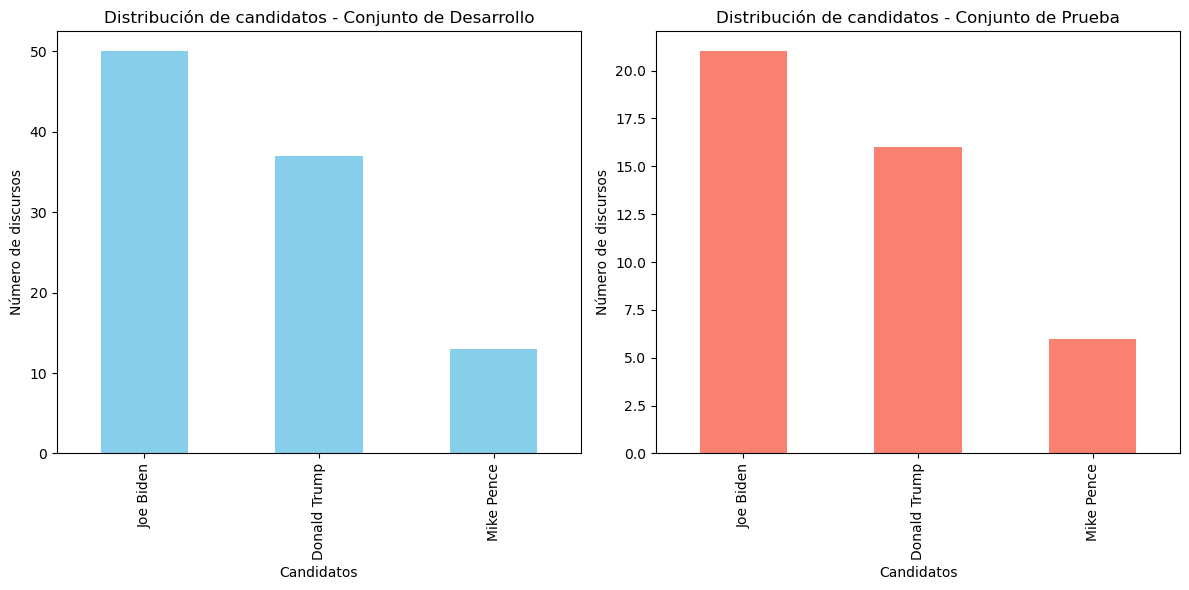

In [22]:
# 2: Visualización de la proporción de cada candidato por conjunto

import matplotlib.pyplot as plt

def plot_candidate_distribution(y_dev, y_test):
    plt.figure(figsize=(12, 6))

    # Gráfico de barras para el conjunto de desarrollo
    plt.subplot(1, 2, 1)
    y_dev.value_counts().plot(kind='bar', color='skyblue')
    plt.title('Distribución de candidatos - Conjunto de Desarrollo')
    plt.xlabel('Candidatos')
    plt.ylabel('Número de discursos')

    # Gráfico de barras para el conjunto de prueba
    plt.subplot(1, 2, 2)
    y_test.value_counts().plot(kind='bar', color='salmon')
    plt.title('Distribución de candidatos - Conjunto de Prueba')
    plt.xlabel('Candidatos')
    plt.ylabel('Número de discursos')

    plt.tight_layout()
    plt.show()

plot_candidate_distribution(y_dev, y_test)


In [23]:
# 3: Transforme el texto del conjunto de entrenamiento a la representación numérica (features) de conteo de palabras o bag of words.


vectorizer = CountVectorizer(
    stop_words=stopwords.words("english"),
    lowercase=True,
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(1, 2)
)

X_dev_counts = vectorizer.fit_transform(X_dev)
print(f"Dimensiones de la matriz de conteo: {X_dev_counts.shape}")



Dimensiones de la matriz de conteo: (100, 205690)


In [24]:
# 4: Obtenga la representación numérica Term Frequency - Inverse Document Frequency.

X_dev_tfidf = TfidfTransformer().fit_transform(X_dev_counts)
print(f"Dimensiones de la matriz TF-IDF: {X_dev_tfidf.shape}")



Dimensiones de la matriz TF-IDF: (100, 205690)


In [25]:
X_dev_tfidf

<100x205690 sparse matrix of type '<class 'numpy.float64'>'
	with 406165 stored elements in Compressed Sparse Row format>

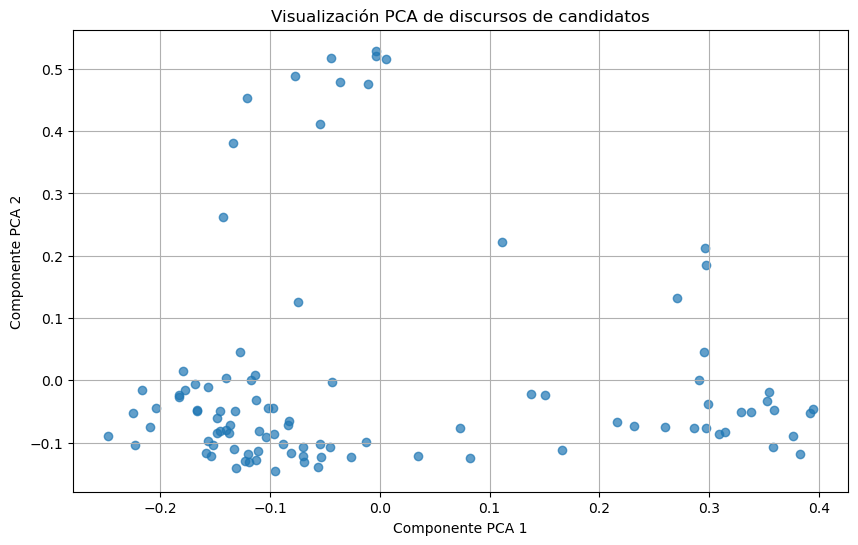

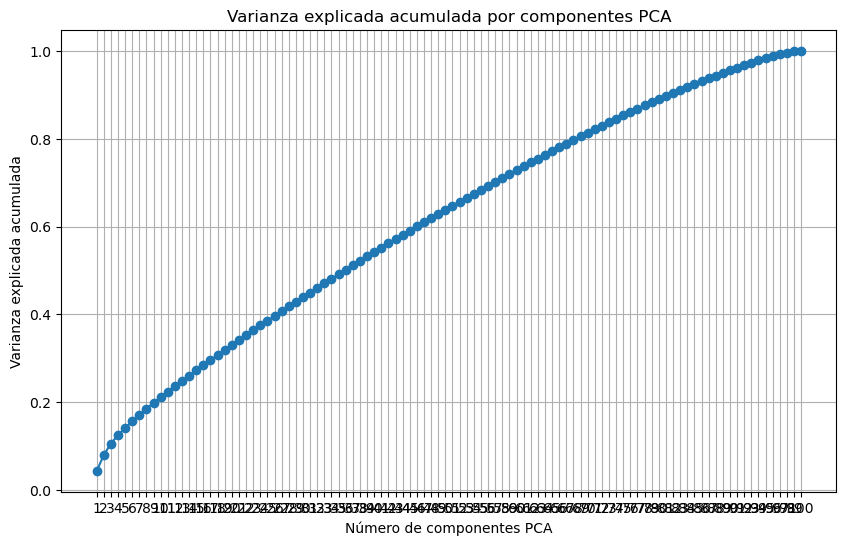

In [29]:
# 5 :Muestre en un mapa el conjunto de entrenamiento, utilizando las dos primeras componentes PCA sobre los vectores de tf-idf.

pca = PCA(n_components=100)
X_dev_pca = pca.fit_transform(X_dev_tfidf.toarray())

plt.figure(figsize=(10, 6))
plt.scatter(X_dev_pca[:, 0], X_dev_pca[:, 1], alpha=0.7)
plt.title('Visualización PCA de discursos de candidatos')
plt.xlabel('Componente PCA 1')
plt.ylabel('Componente PCA 2')
plt.grid()
plt.show()


# Haga una visualización que permita entender cómo varía la varianza explicada a medida que se agregan componentes (e.g: hasta 10 componentes).

plt.figure(figsize=(10, 6))
plt.plot(range(1, 101), np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title('Varianza explicada acumulada por componentes PCA')
plt.xlabel('Número de componentes PCA')
plt.ylabel('Varianza explicada acumulada')
plt.grid()
plt.xticks(range(1, 101))
plt.show()



## Parte 2: Entrenamiento y Evaluación de Modelos


Accuracy del modelo Naive Bayes: 0.86


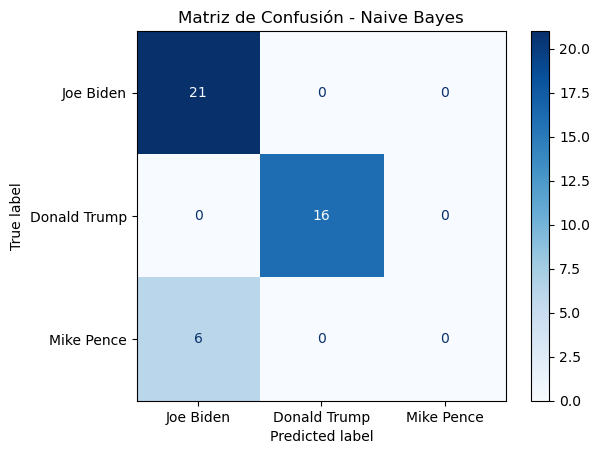

Candidato: Joe Biden, Precision: 0.78, Recall: 1.00
Candidato: Donald Trump, Precision: 1.00, Recall: 1.00
Candidato: Mike Pence, Precision: 0.00, Recall: 0.00


/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
# 1: Entrene el modelo Multinomial Naive Bayes, luego utilícelo para predecir sobre el conjunto de test, y reporte el valor de accuracy y la matriz de confusión. Reporte el valor de precision y recall para cada candidato. 
# Calcular matriz de confusión Sugerencia: utilice el método from_predictions de ConfusionMatrixDisplay para realizar la matriz.

# Entrenamiento del modelo Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_dev_tfidf, y_dev)

# Predicción sobre el conjunto de test
y_pred = nb_model.predict(TfidfTransformer().fit_transform(vectorizer.transform(X_test)))
# Reporte de accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo Naive Bayes: {accuracy:.2f}")
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=top_3_candidates)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_3_candidates)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Naive Bayes')
plt.show()
# Reporte de precision y recall
precision = precision_score(y_test, y_pred, average=None, labels=top_3_candidates)
recall = recall_score(y_test, y_pred, average=None, labels=top_3_candidates)
for candidate, prec, rec in zip(top_3_candidates, precision, recall):
    print(f"Candidato: {candidate}, Precision: {prec:.2f}, Recall: {rec:.2f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejores parámetros encontrados:
{'alpha': 0.01, 'fit_prior': True}


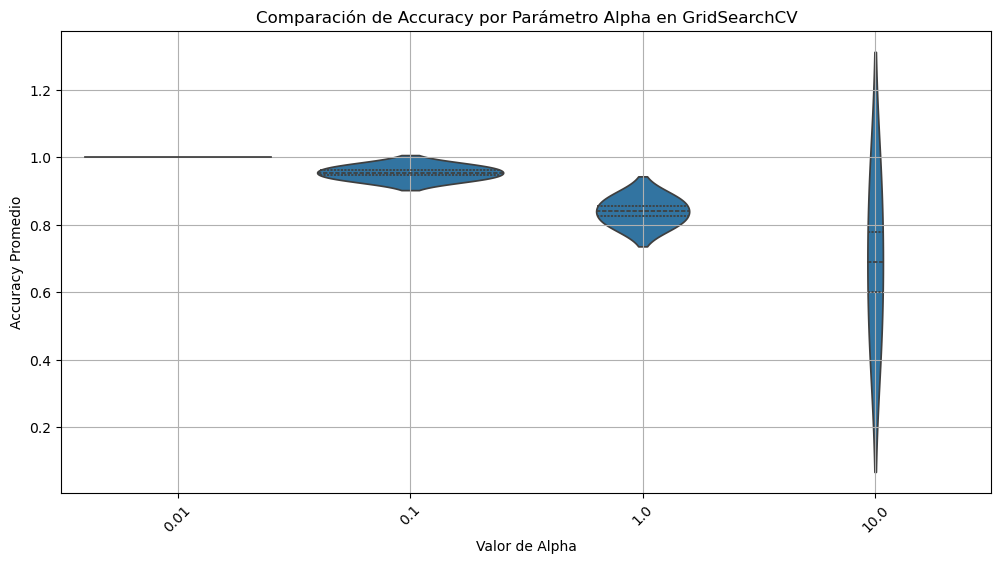

In [31]:
# 2: Implemente una búsqueda de hiperparámetros usando GridSearchCV.

GridSearchCV_params = {
    'alpha': [0.01, 0.1, 1.0, 10.0],
    'fit_prior': [True, False]
}
grid_search = GridSearchCV(
    MultinomialNB(),
    param_grid=GridSearchCV_params,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_dev_tfidf, y_dev)
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

# Genere una visualización que permita comparar las métricas (e.g: accuracy) de los distintos modelos entrenados, viendo el valor promedio y variabilidad de las mismas en todos los splits (e.g: en un gráfico de violín).

violin_data = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(12, 6))
sns.violinplot(x='param_alpha', y='mean_test_score', data=violin_data, inner='quartile')
plt.title('Comparación de Accuracy por Parámetro Alpha en GridSearchCV')
plt.xlabel('Valor de Alpha')
plt.ylabel('Accuracy Promedio')
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [ ]:
# 3: Elija el mejor modelo (mejores parámetros) y vuelva a entrenar sobre todo el conjunto de entrenamiento disponible (sin quitar datos para validación). Reporte el valor final de las métricas y la matriz de confusión.


In [ ]:
# 4: Evalúe con validación cruzada al menos un modelo más (dentro de scikit-learn) aparte de Multinomial Naive Bayes para clasificar el texto utilizando las mismas features de texto.


In [1]:
# 5: Evalúe el problema cambiando al menos un candidato. En particular, observe el (des)balance de datos y los problemas que pueda generar, así como cualquier indicio que pueda ver en el mapeo previo con PCA.

In [ ]:
# OPCIONAL: Repetir la clasificación con los tres candidatos con más discursos, pero esta vez clasificando a nivel de párrafos y no de discursos enteros.
